In [88]:
import pandas as pd
import numpy as np
data = pd.read_csv("content/Data.csv")

data = data.drop(columns=["VD", "VE", "tempo"])

data.index = (np.arange(0, len(data), 1).astype(float) * 0.07).round(5)


data = data.rename(columns={
    "Setpoint VD": "Wd",
    "Setpoint VE": "We",
    "Theta": "theta(Wd,We)",
    "X": "x(Wd,We)",
    "Y": "y(Wd,We)",
})

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

def PlotTimeSeries(df, img_name="data.svg", PlotOut=True):    
    # Estilo Seaborn
    sns.set_theme(style="whitegrid")

    # Criando a figura
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plotando Wd e We como linhas
    sns.lineplot(x=df.index, y=df["Wd"], ax=ax1, marker="o", label="Wd", color="red", linewidth=2)
    sns.lineplot(x=df.index, y=df["We"], ax=ax1, marker="o", label="We", color="blue", linewidth=2)

    if PlotOut:
        ax2 = ax1.twinx()
        sns.lineplot(x=df.index, y=df["theta(Wd,We)"], ax=ax2, marker="o", label="theta(Wd,We)", color="orange", linestyle="dashed", linewidth=2)
        ax2.set_ylabel("Posição Angular", fontsize=12, color="gray")

    # Ajustando os rótulos dos eixos
    ax1.set_xlabel("Tempo (s) - Período de amostragem (T=0.07 s)", fontsize=12)
    ax1.set_ylabel("Velocidade Angular", fontsize=12, color="black")

    # plt.xticks(df.index[::10], rotation=45, fontsize=1)  

    # Adicionando legendas
    ax1.legend(loc="upper left")
    if PlotOut:
        ax2.legend(loc="upper right")

    # Título
    plt.title("Posição angular em função da velocidade nas rodas", fontsize=14)

    # Salvando o gráfico
    plt.savefig(f"content/{img_name}", format="svg", dpi=600)

    # Exibindo o gráfico
    plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

def GetData(df, size=32):
    df = df.head(size)
    display(df)
    PlotTimeSeries(
        df = df
    )
    # Split into train (70%), validation (15%), and test (15%) sets
    train_data, temp_data = train_test_split(df, test_size=0.3, shuffle=False)
    valid_data, test_data = train_test_split(temp_data, test_size=0.5, shuffle=False)
    
    return train_data, valid_data, test_data

,"x(Wd,We)","y(Wd,We)","theta(Wd,We)",Wd,We
0.00,0.00,1.4,0.00,0.093363,0.084131
0.07,0.00,1.4,0.00,0.093363,0.084131
0.14,0.00,1.4,0.00,0.093363,0.084131
0.21,0.00,1.4,0.00,0.093363,0.084131
0.28,0.00,1.4,0.00,0.093363,0.084131
0.35,0.00,1.4,0.00,0.108489,0.084131
0.42,0.00,1.4,0.00,0.108489,0.084131
0.49,0.00,1.4,0.01,0.320257,0.084131
0.56,0.00,1.4,0.02,0.330341,0.084131
0.63,0.00,1.4,0.02,0.179078,0.099349


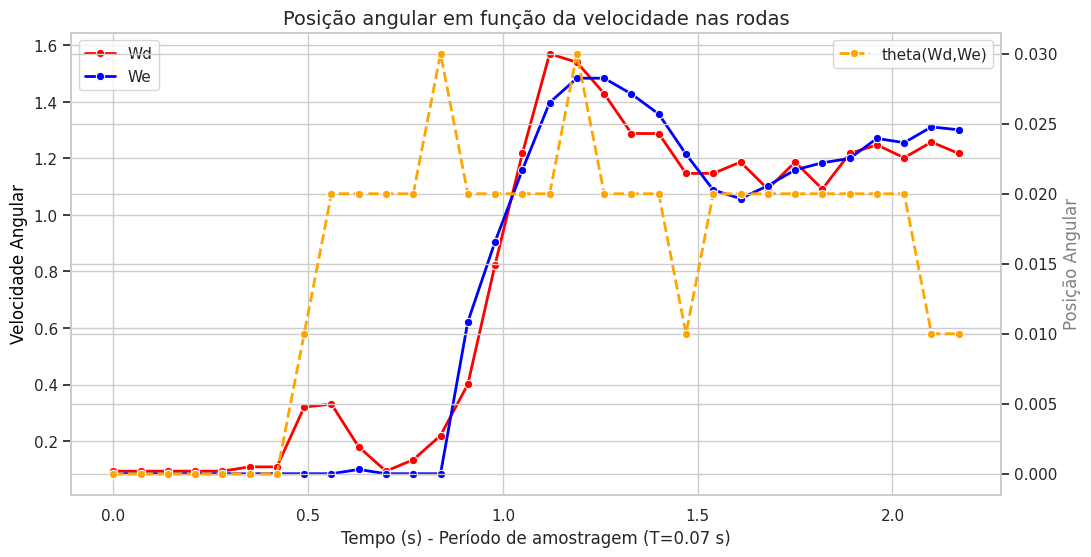

In [ ]:
# Define predictors and target
PREDICTORS = ["Wd", "We"]
TARGET = "theta(Wd,We)"
scaler = StandardScaler()
data[PREDICTORS] = scaler.fit_transform(data[PREDICTORS])

train_data, valid_data, test_data = GetData(size=32)

# Convertendo para arrays numpy
train_x = train_data[PREDICTORS].to_numpy()
train_y = train_data[[TARGET]].to_numpy()

x_val = valid_data[PREDICTORS].to_numpy()
y_val = valid_data[[TARGET]].to_numpy()

x_test = test_data[PREDICTORS].to_numpy()
y_test = test_data[[TARGET]].to_numpy()

In [ ]:
import matplotlib.pyplot as plt
import keras
from keras import layers, models, regularizers
from keras.callbacks import EarlyStopping

def compile_model(model, epochs=100):
    # Compilando o modelo
    model.compile(loss="mse", optimizer="adam")

    # Definindo o early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


    # Treinando o modelo
    history = model.fit(
        train_x, train_y,
        epochs=epochs,
        validation_data=(x_val, y_val),
        callbacks=[early_stop],
        verbose=False
    )

    # Avaliando o modelo
    mse_v = model.evaluate(x_val, y_val)
    print(f"Validation MSE: {mse_v:.4f}")
    
    mse_t = model.evaluate(x_test, y_test)
    print(f"Test MSE: {mse_t:.4f}")

    # Plotando o histórico de treinamento
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()